[Signal Names] MAYBE WROING

SamplePeriod: 50 μs

SampleTime: 10.237 s

signal1  ID:0x23040000  Name:Speed loop reference  Unit:rpm

signal2  ID:0x60690000  Name:Speed loop feedback  Unit:rpm

End Time: 6.00088 s
Sampling Frequency: 10.0 kHz

index_begin 1
index_end -4302
time_begin: 0.0001 s
time_end 5.57068 s

Max reference speed: 100.0
Max measured speed: 99.8082
Min reference speed: -100.0
Min measured speed: -99.8083

Time Span: 5.57009 s


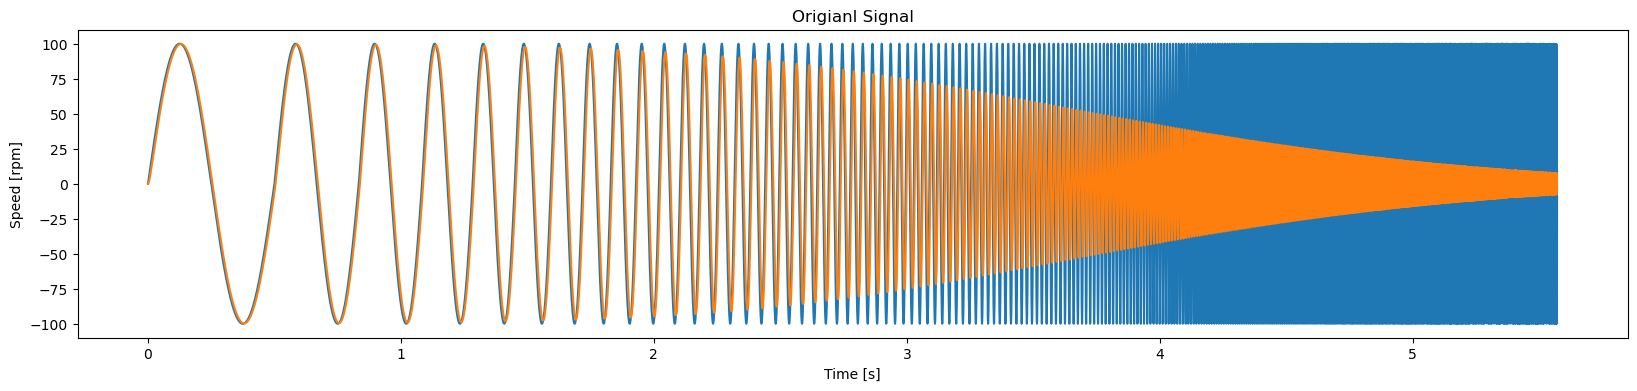

In [42]:
import pandas as pd
from pylab import plt, np
from pylab import fft
import math
%matplotlib inline

# Target file name
fname = 'data/SpeedSweepingData.txt'
max_freq = 400 # [Hz]

# Read name and meta data
signal_names = []
with open(fname, 'r', encoding='gb2312') as f:
    for _ in range(5):
        line = f.readline()
        print(line)
        if 'Unit' in line:
            signal_name = line[line.find('Name')+5 : line.find('Unit')]
            signal_names.append(signal_name)

# read data as Data Frame
df = pd.read_csv(fname, skiprows=7, sep='\s+', encoding='gb2312', names=['Time(s)', signal_names[0], signal_names[1]])

# Unpack as Series
time  = df['Time(s)']
x_ref = df[signal_names[0]]
x_qep = df[signal_names[1]] #+ 100 # add dc offset for test

# Basic DFT parameters
# N = df.shape[0]
Ts = df['Time(s)'][1] - df['Time(s)'][0]
samplingFreq = 1/Ts
EndTime = df['Time(s)'].iloc[-1]
print('End Time:', EndTime, 's')
print('Sampling Frequency:', samplingFreq*1e-3, 'kHz')
# print('Number of Points:', N)
print()

# Plot signal in time domain
for index, value in enumerate(x_ref):
    if value!=x_ref.iloc[0]:
        index_begin = index
        time_begin = index*Ts
        break
for index, value in enumerate(x_ref[::-1]):
    if value!=x_ref.iloc[-1]:
        index_end = -index
        time_end = EndTime - index*Ts
        break
print('index_begin', index_begin)
print('index_end', index_end)
print('time_begin:', time_begin, 's')
print('time_end', time_end,   's')
time  = time [index_begin:index_end]
x_ref = x_ref[index_begin:index_end]
x_qep = x_qep[index_begin:index_end]
plt.figure(figsize=(20,4))
plt.title('Origianl Signal')
plt.xlabel('Time [s]')
plt.ylabel('Speed [rpm]')
plt.plot(time, x_ref, label='ref')
plt.plot(time, x_qep, label='qep')

# plt.xlim([0, 8/target_Hz])
print()
print('Max reference speed:', max(x_ref))
print('Max measured speed:', max(x_qep))
print('Min reference speed:', min(x_ref))
print('Min measured speed:', min(x_qep))


print()
TimeSpan = time.iloc[-1]
print('Time Span:', TimeSpan, 's')

Frequency Resolution: 2.00 Hz | Max Amplitude: 99.81 rpm | Corresponding Frequency: 2.00 Hz
Frequency Resolution: 3.00 Hz | Max Amplitude: 99.57 rpm | Corresponding Frequency: 3.00 Hz
Frequency Resolution: 4.00 Hz | Max Amplitude: 99.23 rpm | Corresponding Frequency: 4.00 Hz
Frequency Resolution: 5.00 Hz | Max Amplitude: 98.82 rpm | Corresponding Frequency: 5.00 Hz
Frequency Resolution: 6.00 Hz | Max Amplitude: 98.33 rpm | Corresponding Frequency: 6.00 Hz
Frequency Resolution: 7.00 Hz | Max Amplitude: 97.75 rpm | Corresponding Frequency: 7.00 Hz
Frequency Resolution: 8.00 Hz | Max Amplitude: 97.08 rpm | Corresponding Frequency: 8.00 Hz
Frequency Resolution: 9.00 Hz | Max Amplitude: 96.37 rpm | Corresponding Frequency: 9.00 Hz
Frequency Resolution: 10.00 Hz | Max Amplitude: 95.58 rpm | Corresponding Frequency: 10.00 Hz
Frequency Resolution: 11.00 Hz | Max Amplitude: 94.76 rpm | Corresponding Frequency: 11.00 Hz
Frequency Resolution: 12.00 Hz | Max Amplitude: 93.93 rpm | Corresponding Fr

399

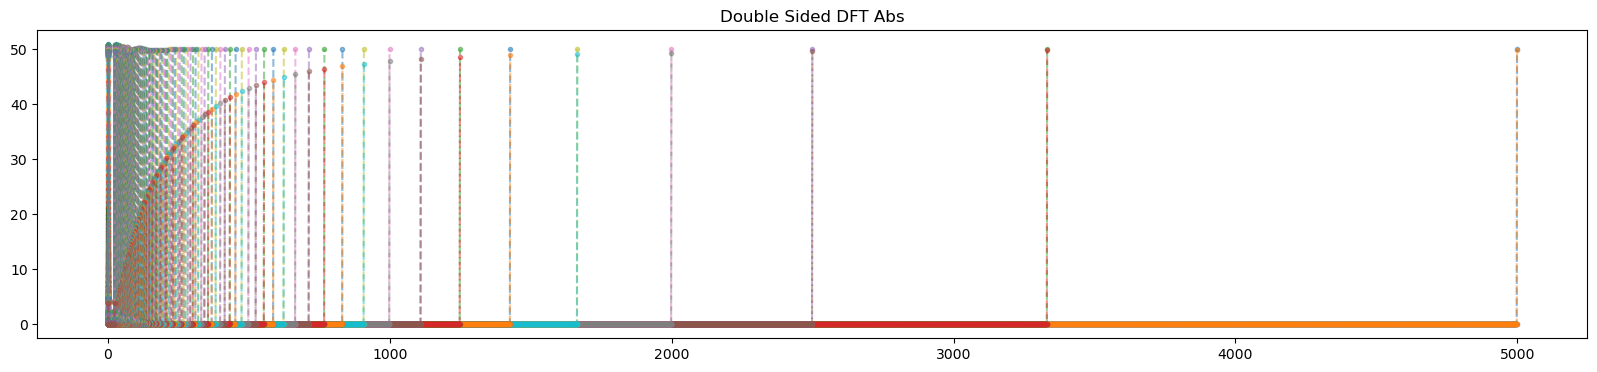

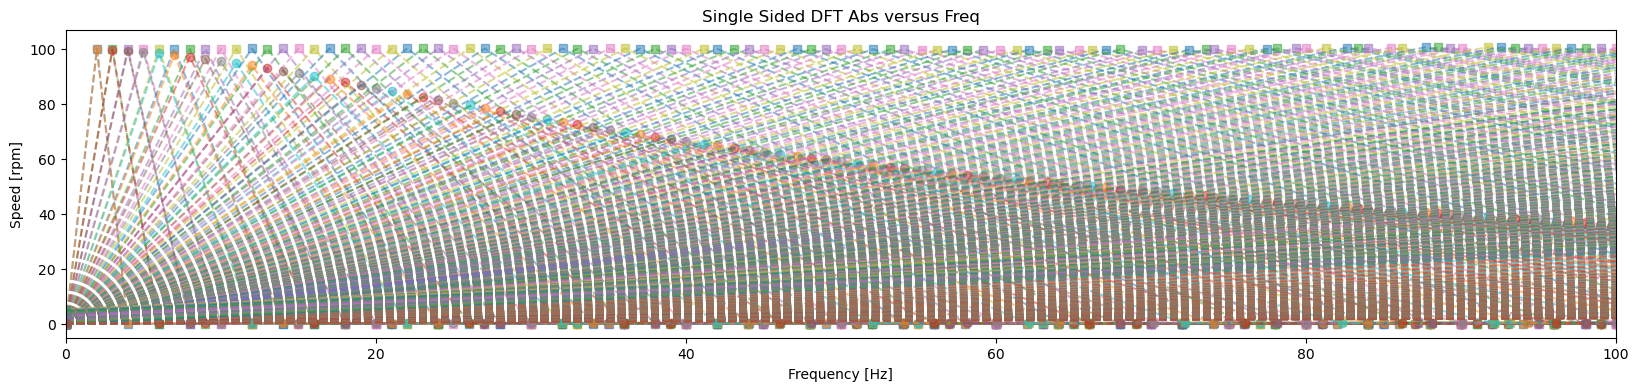

In [43]:
list_qep_max_amplitude = []
list_qep_max_frequency = []
list_ref_max_amplitude = []
list_ref_max_frequency = []

index_single_tone_begin = 0
index_single_tone_end = 0
# max_freq = 5 # debug
for freq in range(2, max_freq): # datum point at 1 Hz is absent
    period = 1/freq
    index_single_tone_begin = index_single_tone_end
    index_single_tone_end = index_single_tone_begin + int(period/Ts)
        
    ST_time  =  time[index_single_tone_begin:index_single_tone_end]
    ST_x_ref = x_ref[index_single_tone_begin:index_single_tone_end]
    ST_x_qep = x_qep[index_single_tone_begin:index_single_tone_end]

    x_ref_dft = fft(ST_x_ref)
    x_qep_dft = fft(ST_x_qep)

    # Do DFT (Raw)
    N = len(ST_time)
    plt.figure(1, figsize=(20,4))
    plt.plot(abs(x_ref_dft)/N, '.--', alpha=0.5, label='x_ref-dft');
    plt.plot(abs(x_qep_dft)/N, '.--', alpha=0.5, label='x_qep-dft');
    #     plt.legend(loc='center')

    # Convert raw DFT results into human-friendly forms
    resolution = samplingFreq/N # [Hz]
    Neff = math.ceil(N/2) # number of effective points
                          # 其实理论上来说，这里是比较复杂的，当N为偶数的时候，奈奎斯特频率就是采样频率的二分之一？当N为奇数的时候，还会多出一个分量，这个分量和直流分量是一对，具体我忘了……可能有错
    x_ref_hat = np.append(x_ref_dft[0]/N, 2*x_ref_dft[1:Neff+1]/N)  # 原始复数dft结果（双边变单边，除了直流分量，其他分量全部要乘以2）
    x_qep_hat = np.append(x_qep_dft[0]/N, 2*x_qep_dft[1:Neff+1]/N)

    # Plot DFT for human to read
    plt.figure(2, figsize=(20,4))
    plt.plot(np.array(list(range(0, Neff+1)))*resolution, abs(x_ref_hat), '--s', alpha=0.5, label='ref');
    plt.plot(np.array(list(range(0, Neff+1)))*resolution, abs(x_qep_hat), '--o', alpha=0.5, label='qep');

    # qep related data collection
    max_amplitude = max(abs(x_qep_hat));      list_qep_max_amplitude.append(max_amplitude)
    max_index     = np.argmax(abs(x_qep_hat))
    max_frequency = (max_index+0)*resolution; list_qep_max_frequency.append(max_frequency)

    print(f'Frequency Resolution: {resolution:.2f} Hz', end=' | ')
    print(f'Max Amplitude: {max_amplitude:.2f} rpm', end=' | ')
    print(f'Corresponding Frequency: {max_frequency:.2f} Hz')

    # ref related data collection
    max_amplitude = max(abs(x_ref_hat));      list_ref_max_amplitude.append(max_amplitude)
    max_index     = np.argmax(abs(x_ref_hat))
    max_frequency = (max_index+0)*resolution; list_ref_max_frequency.append(max_frequency)
    
    # stop and inspect
    #     a = input()
    #     print(freq, 'Hz')

plt.figure(1)
plt.title('Double Sided DFT Abs')

plt.figure(2)
plt.title('Single Sided DFT Abs versus Freq')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Speed [rpm]')
plt.xlim([0, 100])
freq

list_ref_max_frequency: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 2

Text(0, 0.5, 'Speed [rpm]')

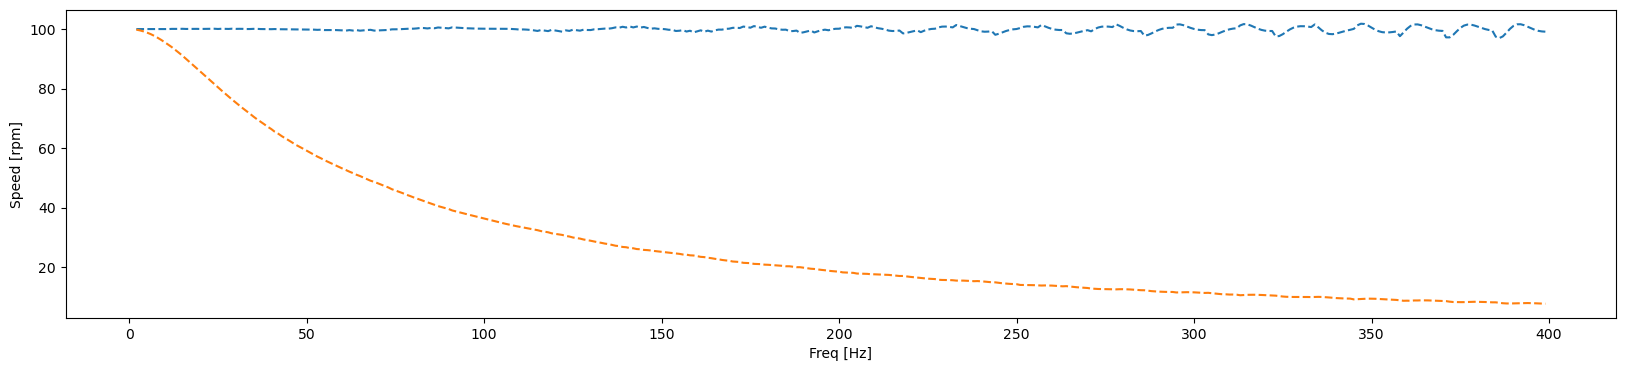

In [41]:
plt.figure(3, figsize=(20,4))
if max_freq>500:
    print('max_freq > 500')
    list_ref_max_frequency = list(range(2, max_freq))
    list_qep_max_frequency = list(range(2, max_freq))
print('list_ref_max_frequency:', list_ref_max_frequency)
print('list_qep_max_frequency:', list_qep_max_frequency)

plt.plot(list_ref_max_frequency, list_ref_max_amplitude, '--')
plt.plot(list_qep_max_frequency, list_qep_max_amplitude, '--')
plt.xlabel('Freq [Hz]')
plt.ylabel('Speed [rpm]')

Text(0, 0.5, 'closed-loop transfer function amplitude [1]')

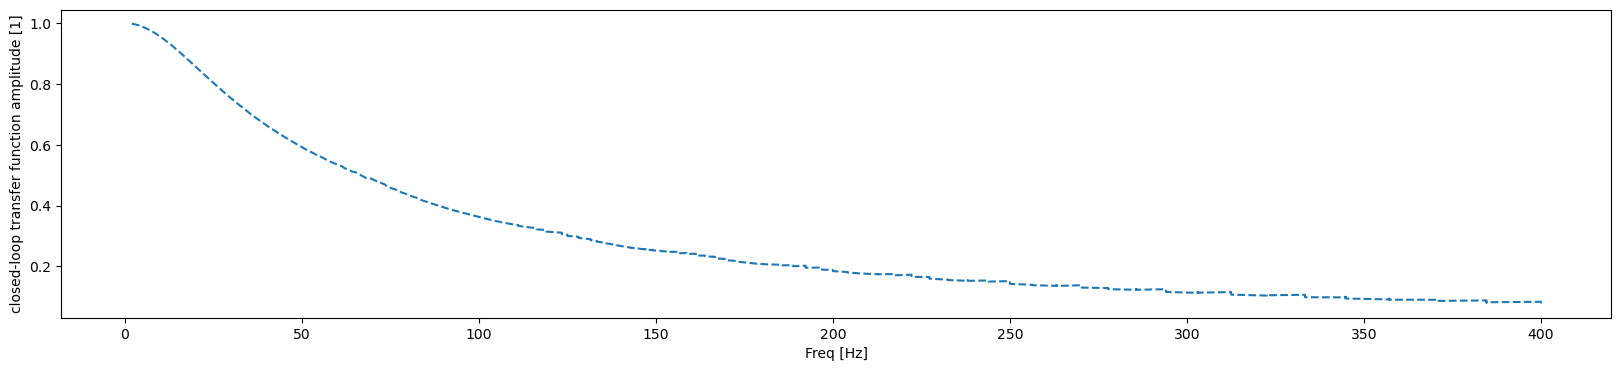

In [36]:
plt.figure(4, figsize=(20,4))
closed_loop_transfer_function = [qep/ref for ref, qep in zip(list_ref_max_amplitude, list_qep_max_amplitude)]
plt.plot(list_qep_max_frequency, closed_loop_transfer_function, '--')
plt.xlabel('Freq [Hz]')
plt.ylabel('closed-loop transfer function amplitude [1]')

Text(0, 0.5, 'closed-loop transfer function amplitude [dB]')

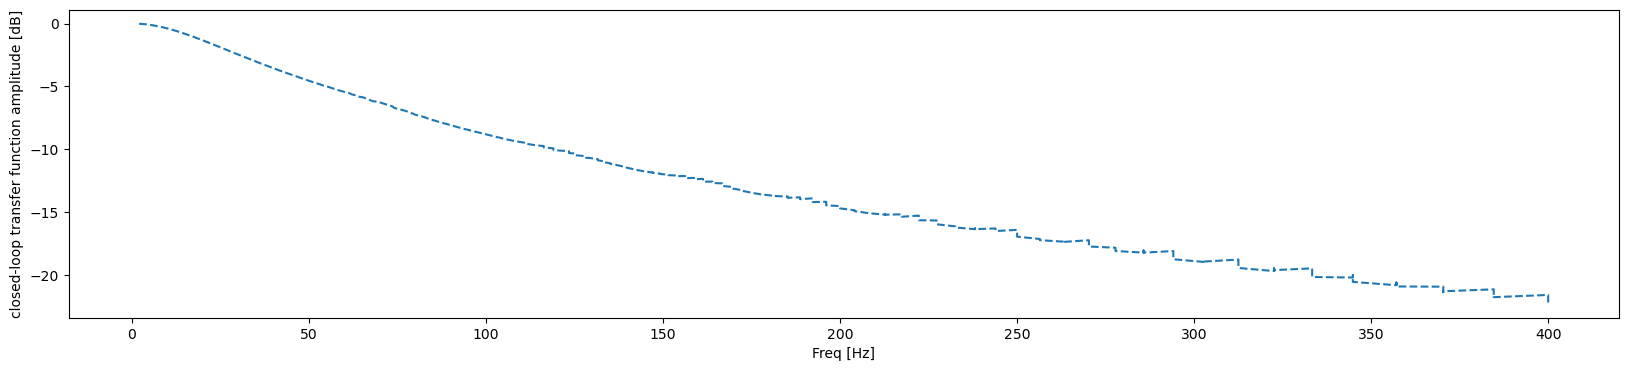

In [37]:
plt.figure(4, figsize=(20,4))
closed_loop_transfer_function = [qep/ref for ref, qep in zip(list_ref_max_amplitude, list_qep_max_amplitude)]
plt.plot(list_qep_max_frequency, [20*np.log10(el) for el in closed_loop_transfer_function], '--')
plt.xlabel('Freq [Hz]')
plt.ylabel('closed-loop transfer function amplitude [dB]')

In [ ]:
np.log(1), np.log10(1/10), np.log10(1/100)

In [ ]:
20*np.log(1), 20*np.log10(0.1), 20*np.log10(0.01)